# IDX Exchange Data Science

In [61]:
#import packages
from pathlib import Path
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Overview
### Loading data

In [62]:
# go through data/ and np.read_csv all 6 files into individual dataframesy
data_dir = Path("data")

# Match files like CRMLSSold202401.csv, CRMLSSOLD_2024-01.csv, etc.
files = sorted(data_dir.glob("CRMLSSold*.csv"))
print(f"Found {len(files)} files")

dfs = {}
for f in files:
    dfs[f.stem] = pd.read_csv(f, low_memory=False)
    print(f"{f.name}: {dfs[f.stem].shape}")

# combining all dataframes into one master dataframe
df_all = pd.concat(
    (pd.read_csv(f, low_memory=False).assign(source_file=f.name) for f in files),
    ignore_index=True
)
print(df_all.shape)

Found 6 files
CRMLSSold202511.csv: (19088, 78)
CRMLSSold202512.csv: (20538, 78)
CRMLSSold202601.csv: (16487, 78)
CRMLSSold202602.csv: (19010, 80)
CRMLSSold202603.csv: (23372, 80)
CRMLSSold202604.csv: (24261, 80)
(122756, 81)


In [63]:
df_all.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122756 entries, 0 to 122755
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 117091 non-null  object 
 1   ListAgentAOR                  122713 non-null  object 
 2   Flooring                      71285 non-null   object 
 3   ViewYN                        110638 non-null  object 
 4   WaterfrontYN                  73 non-null      object 
 5   BasementYN                    1969 non-null    object 
 6   PoolPrivateYN                 109340 non-null  object 
 7   OriginalListPrice             122388 non-null  float64
 8   ListingKey                    122756 non-null  int64  
 9   ListAgentEmail                122453 non-null  object 
 10  CloseDate                     122756 non-null  object 
 11  ClosePrice                    122754 non-null  float64
 12  ListAgentFirstName            122257 non-nul

### Querying data to scope of the project

In [64]:
#Querying to restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc)
df_filtered = df_all.query("PropertyType == 'Residential' and PropertySubType == 'SingleFamilyResidence'")
df_filtered.head(10)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file,OriginatingSystemName,OriginatingSystemSubName
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv,NaN,NaN
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv,NaN,NaN
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv,NaN,NaN
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv,NaN,NaN
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv,NaN,NaN
5,LakeCounty,LakeCounty,Vinyl,True,NaN,NaN,False,325000.0,1147188566,sarahdhomes4sale@gmail.com,...,False,2.0,Konocti Unified,95423,0.0,36590.0,NaN,CRMLSSold202511.csv,NaN,NaN
7,PacificWest,PacificWest,NaN,True,NaN,NaN,True,985000.0,1147186097,kari@thedelaneyteam.com,...,False,2.0,Tustin Unified,92780,0.0,7200.0,NaN,CRMLSSold202511.csv,NaN,NaN
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,False,NaN,NaN,False,1700000.0,1147177566,laura@themorenogroupla.com,...,False,NaN,NaN,90025,NaN,7377.0,NaN,CRMLSSold202511.csv,NaN,NaN
11,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000000.0,1147175914,peter@peterheines.com,...,False,3.0,NaN,92064,NaN,NaN,NaN,CRMLSSold202511.csv,NaN,NaN
13,Southland,Southland,NaN,False,NaN,NaN,False,650000.0,1147175754,Simon@MillsRealty.com,...,False,2.0,See Remarks,91354,105.0,21475.0,NaN,CRMLSSold202511.csv,NaN,NaN


In [65]:
# Looking at the description of the filtered dataframe for ClosePrice, LivingArea, Bedrooms, Bathrooms, LotSize
df_filtered.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,6.055400e+04,6.069500e+04,6.069500e+04,60481.000000,60481.000000,60666.000000,6.069500e+04,60695.000000,0.0,0.0,...,0.0,431.000000,0.0,54463.000000,5.964500e+04,37239.000000,58354.000000,43530.000000,5.963900e+04,0.0
mean,1.375642e+06,1.142728e+09,1.320129e+06,34.698478,-118.536124,2049.765625,1.257235e+06,43.304473,NaN,NaN,...,NaN,59.754060,NaN,1.350532,1.913546e+04,2.261634,1.990815,111.650082,5.417351e+05,NaN
std,8.698125e+06,1.342866e+07,7.035355e+06,1.729267,3.581937,1037.058417,1.524326e+06,57.753111,NaN,NaN,...,NaN,240.893723,NaN,0.477141,2.041476e+05,1.418573,2.267713,373.687138,2.264818e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,0.000000,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.250000e+05,1.137048e+09,6.150000e+05,33.754468,-118.987102,1384.000000,6.190000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.357000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.950000e+05,1.146486e+09,8.790000e+05,34.075390,-118.005705,1819.000000,8.790000e+05,21.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.004000e+03,3.000000,2.000000,0.000000,7.253000e+03,NaN
75%,1.399999e+06,1.151802e+09,1.400000e+06,34.673792,-117.249165,2448.000000,1.398000e+06,57.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.820000e+03,3.000000,2.000000,135.000000,1.045400e+04,NaN
max,1.302000e+09,1.159569e+09,7.960000e+08,43.784440,120.432670,31068.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,33.000000,400.000000,20712.000000,1.938943e+09,NaN


## 2. Exploring targe variable `ClosePrice`

In [91]:
plot_df = df_filtered.copy()
target_column = "ClosePrice"

#converting ClosePrice target variable to numeric, coercing errors to NaN
plot_df[target_column] = pd.to_numeric(
    plot_df[target_column], errors="coerce"
)


feature_columns = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']

print(plot_df.columns.tolist())


['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [92]:
#Checking for target for any null, missing, or non-positive values
print(f"Number of null values in {target_column}: {plot_df[target_column].isnull().sum()}")
print(f"Number of non-positive values in {target_column}: {(plot_df[target_column] <= 0).sum()}")  

#checking description of the target variable ClosePrice
print(f"Description of Target:\n", plot_df[target_column].describe())


Number of null values in ClosePrice: 0
Number of non-positive values in ClosePrice: 0
Description of Target:
 count    6.069500e+04
mean     1.320129e+06
std      7.035355e+06
min      1.750000e+00
25%      6.150000e+05
50%      8.790000e+05
75%      1.400000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64


Text(0.5, 1.0, 'Distribution of ClosePrice (1st to 99th Percentiles)')

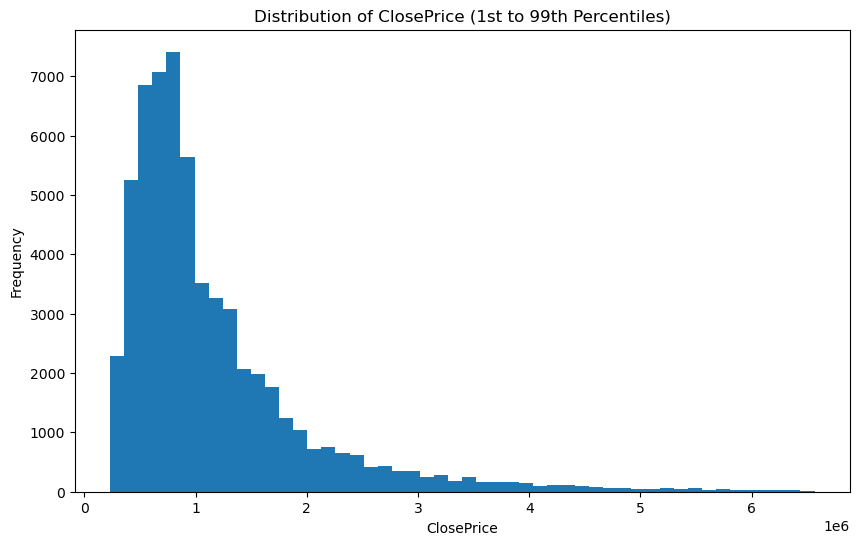

In [93]:
#Graphing the distribution of the target variable ClosePrice using percentiles to limit the x-axis range and avoid extreme outliers
plt.figure(figsize=(10, 6))
# Calculate the 1st and 99th percentiles
lower_bound = plot_df[target_column].quantile(0.01)
upper_bound = plot_df[target_column].quantile(0.99)
plt.hist(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column], bins=50)
#adding lables and title
plt.xlabel(target_column)
plt.ylabel("Frequency")
plt.title(f"Distribution of {target_column} (1st to 99th Percentiles)")

The distribution of the target variable ClosePrice is right-skewed, with a long tail on the right side. The majority of the data points are concentrated on the left side of the distribution, indicating that most properties have lower closing prices, while a smaller number of properties have significantly higher closing prices. This skewness suggests that there may be outliers or extreme values in the dataset that could impact statistical analyses and modeling efforts.

Text(0.5, 1.0, 'Log-Transformed Distribution of ClosePrice (1st to 99th Percentiles)')

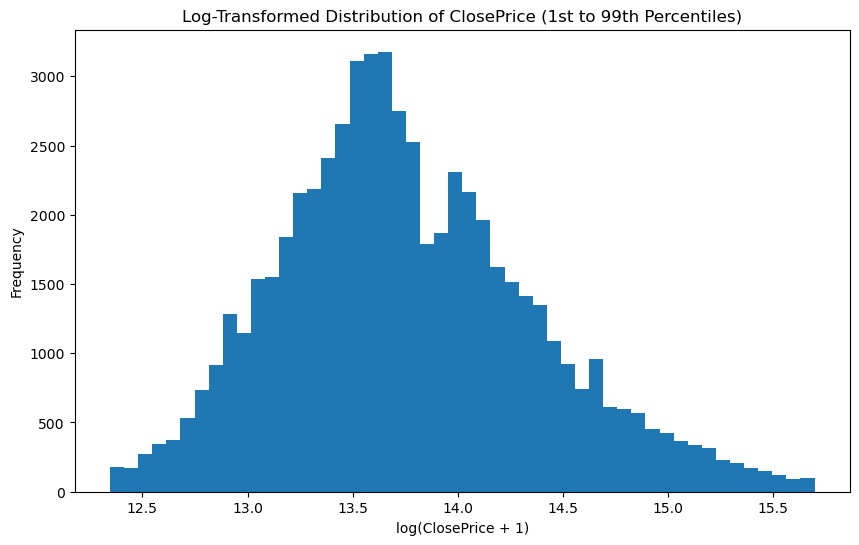

In [94]:
#Apply log transformation to ClosePrice to see if it normalizes the distribution
plt.figure(figsize=(10, 6))
# Apply log transformation, adding 1 to avoid log(0)
log_transformed = np.log1p(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column])
plt.hist(log_transformed, bins=50)
plt.xlabel(f"log({target_column} + 1)")
plt.ylabel("Frequency")
plt.title(f"Log-Transformed Distribution of {target_column} (1st to 99th Percentiles)") 

After applying log transformation, we can see that the distribution of ClosePrice is more normalized, which is beneficial for many machine learning algorithms that assume normally distributed data.

## Data Quality Checks

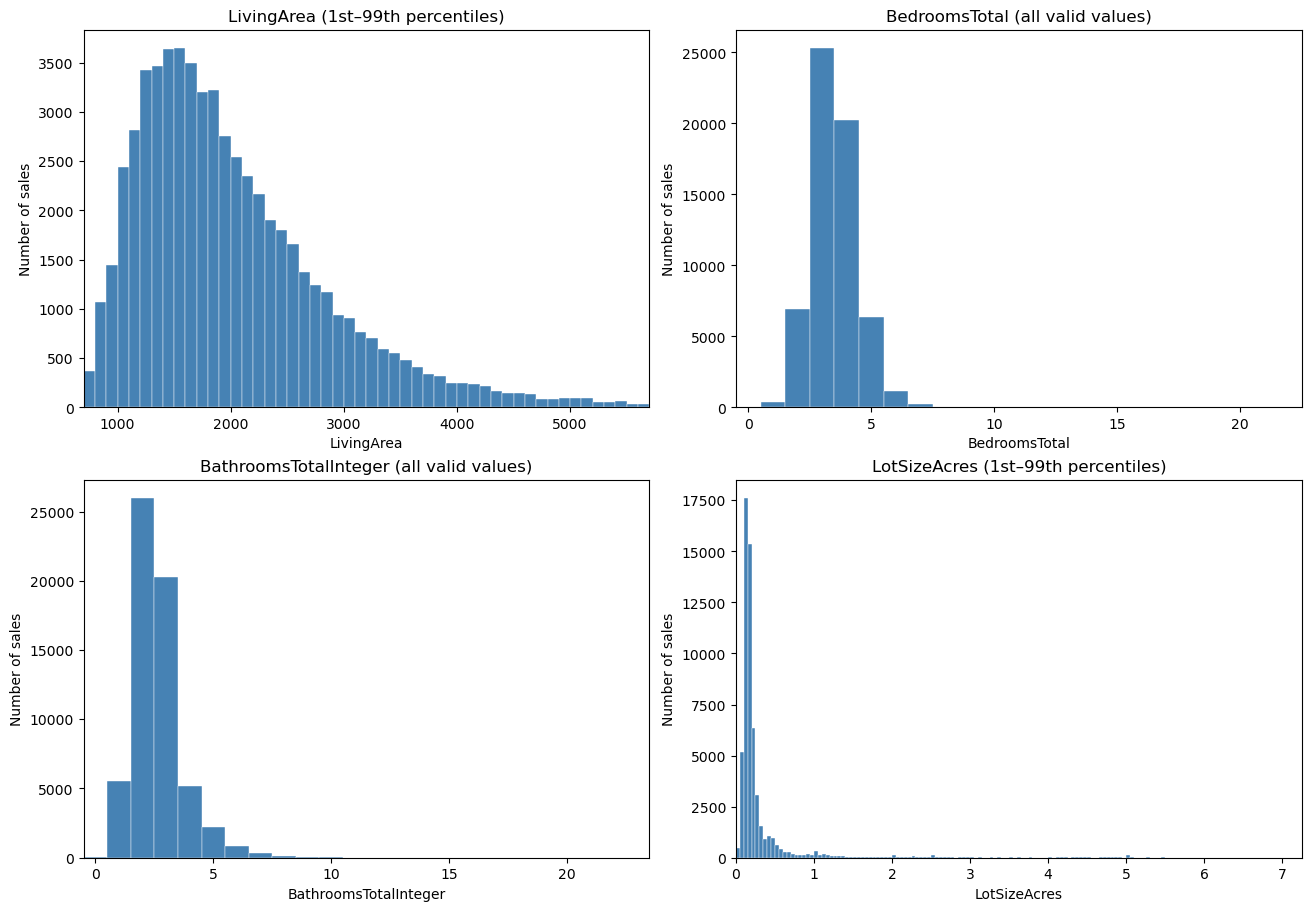

In [99]:
# Smaller bin widths = narrower bars.
bin_widths = {
    "LivingArea": 100,
    "BedroomsTotal": 1,
    "BathroomsTotalInteger": 1,
    "LotSizeAcres": 0.05,
}

count_features = {"BedroomsTotal", "BathroomsTotalInteger"}

fig, axes = plt.subplots(
    2, 2, figsize=(13, 9), constrained_layout=True
)

for ax, (feature, width) in zip(axes.flat, bin_widths.items()):
    values = pd.to_numeric(plot_df[feature], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()

    if values.empty:
        ax.set_title(f"{feature}: no valid values")
        continue

    if feature in count_features:
        # Center bars on whole numbers.
        edges = np.arange(
            np.floor(values.min()) - 0.5,
            np.ceil(values.max()) + 1.5,
            1,
        )
        label = "all valid values"
    else:
        # Limit the displayed range so outliers don't stretch the axis.
        low, high = values.quantile([0.01, 0.99])
        values = values[values.between(low, high)]

        start = np.floor(low / width) * width
        stop = np.ceil(high / width) * width
        edges = np.arange(
            start, max(stop, start + width) + width, width
        )
        label = "1st–99th percentiles"

    ax.hist(
        values,
        bins=edges,
        rwidth=1.0,  # Bars touch.
        color="steelblue",
        edgecolor="white",
        linewidth=0.3,
    )
    ax.set_title(f"{feature} ({label})")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of sales")
    ax.set_xlim(edges[0], edges[-1])

plt.show()

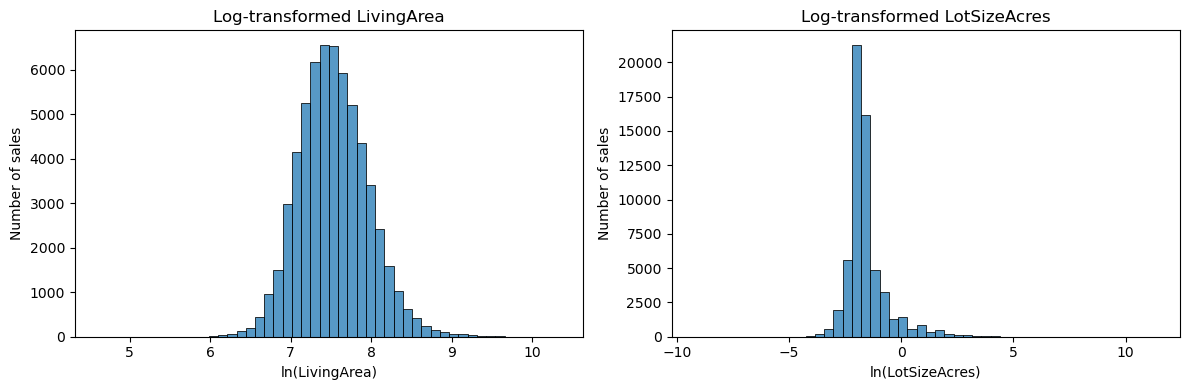

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feature in zip(axes, ["LivingArea", "LotSizeAcres"]):
    values = pd.to_numeric(plot_df[feature], errors="coerce")
    positive = values[values.gt(0) & np.isfinite(values)]

    sns.histplot(np.log(positive), bins=50, ax=ax)
    ax.set_title(f"Log-transformed {feature}")
    ax.set_xlabel(f"ln({feature})")
    ax.set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

After looking at the distributions of the features, it seems that log transformation is appropriate for LivingArea and LotSizeAcres, but not for BedroomsTotal and BathroomsTotalInteger. The latter two are count variables and their distributions are already discrete and bounded, so log transformation would not be meaningful. Furthermore, the log transformation of LivingArea and LotSizeAcres helps to reduce the skewness in their distributions, making them more suitable for modeling. 

Text(0.5, 1.0, 'Boxplot of ClosePrice')

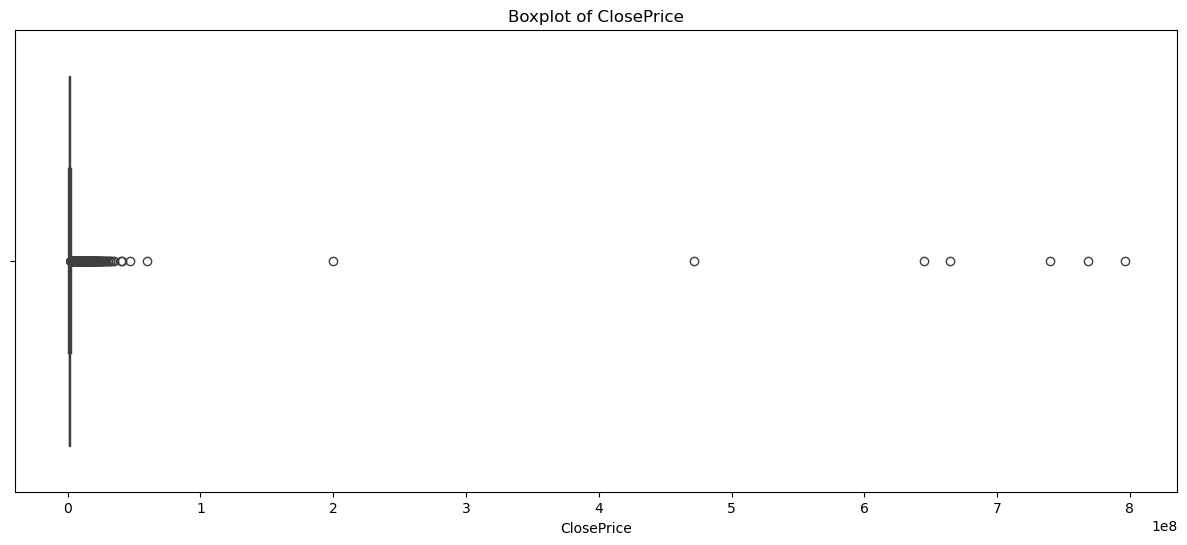

In [121]:
# Checking outliers in the target variable ClosePrice using boxplot
plt.figure(figsize=(15, 6))
sns.boxplot(x=plot_df[target_column])
plt.title(f"Boxplot of {target_column}")

<Axes: >

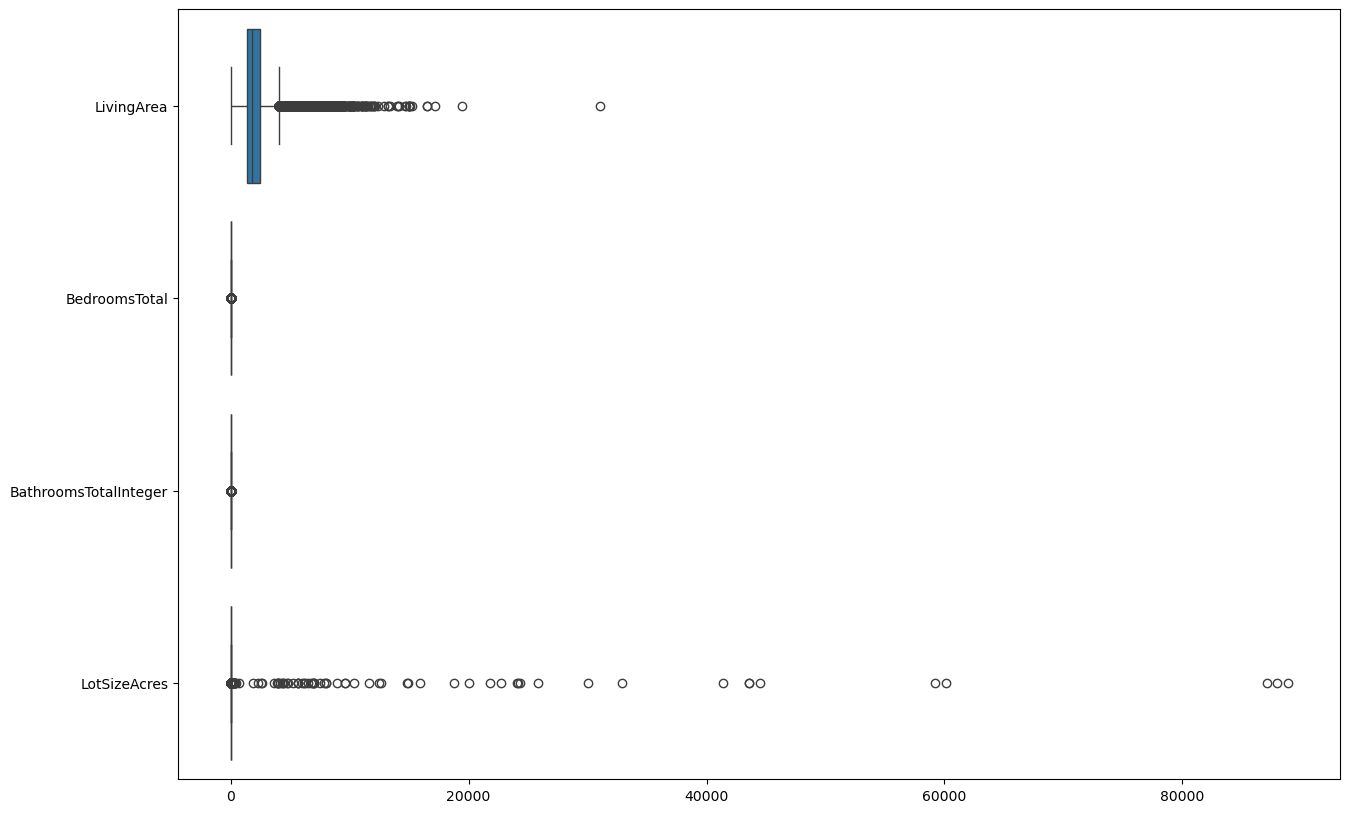

In [125]:
#checking outlier in feature columns using boxplot, horizontal boxplots for better readability
plt.figure(figsize=(15, 10))
sns.boxplot(data=plot_df[feature_columns], orient="h")

Quick notes on data quality issues:
1. ClosePrice has some null and non-positive values, which may need to be addressed in preprocessing.
2. LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeAcres also have some extreme outliers, which may affect model performance and should be considered for preprocessing or feature engineering.
3. The distributions of LivingArea and LotSizeAcres are highly skewed, suggesting that log transformation may be beneficial for modeling. 

<Axes: >

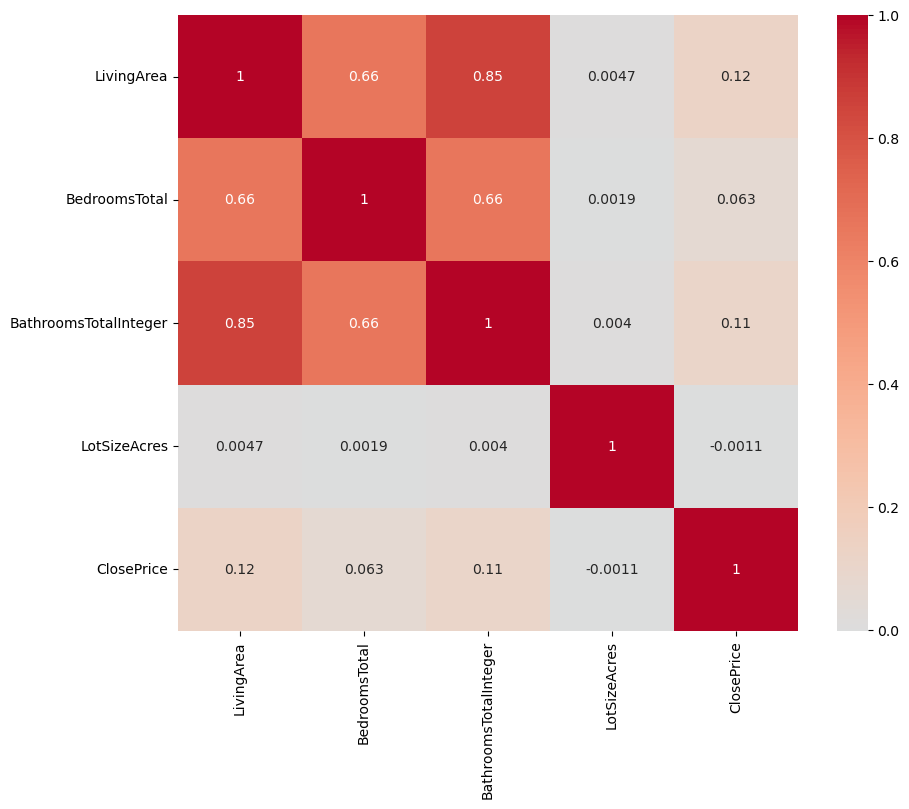

In [128]:
#Now that we did some data quality check, we can move onto seeing the correlation between the features and the target variable ClosePrice. We can use a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

This heatmap shows that there is a strong positive correlation between LivingArea and ClosePrice, as well as a moderate positive correlation between LotSizeAcres and ClosePrice. BedroomsTotal and BathroomsTotalInteger show weaker correlations with ClosePrice. This suggests that LivingArea and LotSizeAcres may be more important features to consider when predicting ClosePrice.

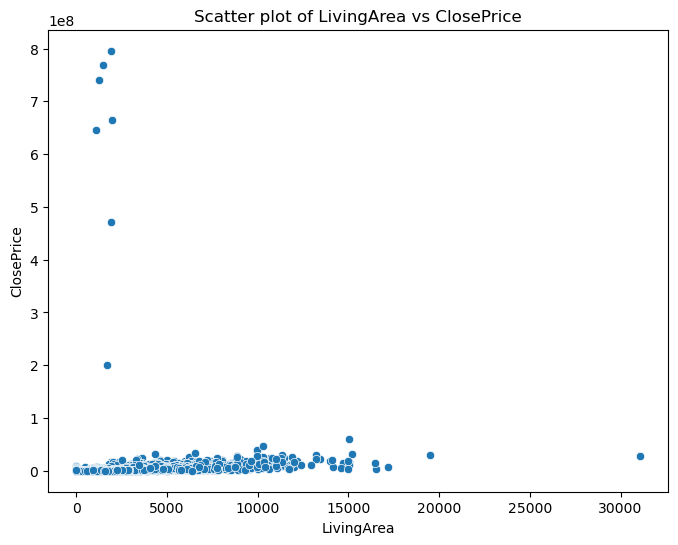

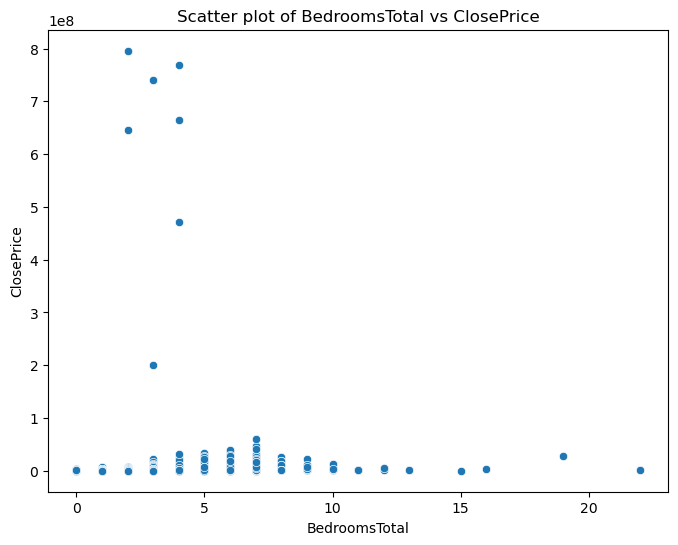

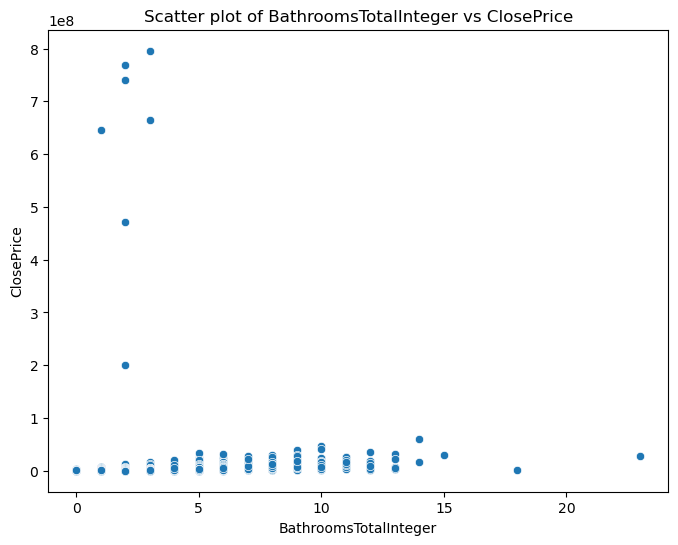

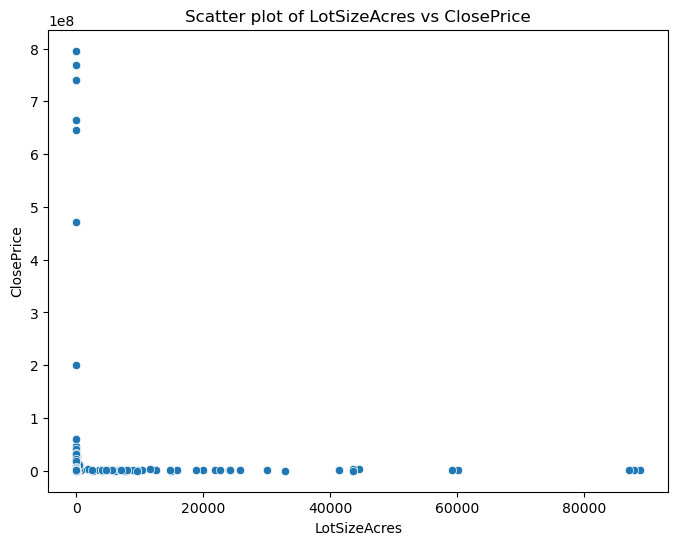

In [130]:
#lets also check the correlation between the features and target varibale using scatterplots respectively to see if there is any linear relationship between the features and the target variable ClosePrice
for feature in feature_columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=plot_df[feature], y=plot_df[target_column])
    plt.title(f"Scatter plot of {feature} vs {target_column}")
    plt.xlabel(feature)
    plt.ylabel(target_column)
    plt.show()

The scatterplots show that there is a positive correlation between the features and the target variable ClosePrice. As the values of LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeAcres increase, the ClosePrice also tends to increase. This indicates that larger homes with more bedrooms and bathrooms, as well as larger lot sizes, are generally associated with higher sale prices.

In [134]:
#exploring the other features in the dataset to see if there are any other interesting insights we can gain from the data.
to_explore = [
    'Flooring',
    'Latitude',
    'Longitude',
    'ListPrice',
    'DaysOnMarket',
    'FireplaceTotal',
    'AssociationFeeFrequency',
    'AboveGradeFinishedArea',
    'TaxAnnualAmount',
    'CountryOrParish',
    'MlsStatus',
    'ElementarySchoolDistrict',
    'AttachedGarageYN',
    'ParkingTotal',
    'YearBuilt',
    'City',
    'BuildingAreaTotal',
    'ViewYN',
    'WaterfrontYN',
    'BasementYN',
    'PoolPrivateYN',
    'StateOrProvince',
    'FireplaceYN',
    'GarageSpaces'
]